In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = {'Week': [1, 2, 3, 4], 'Energy_Used_kWh': [120, 110, 105, 98]}
df = pd.DataFrame(data)

In [ ]:
df['Savings'] = df['Energy_Used_kWh'].shift(1) - df['Energy_Used_kWh']
df

,Week,Energy_Used_kWh,Savings
0,1,120,NaN
1,2,110,10.0
2,3,105,5.0
3,4,98,7.0


In [ ]:
df = pd.read_csv("/content/global-data-on-sustainable-energy (1).csv")

In [ ]:
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [ ]:
ireland_df = df[df['Entity'] == 'Ireland']

In [ ]:
ireland_df = ireland_df.sort_values('Year')

In [ ]:
ireland_df.head()
#filtering the data for a specific country (like Ireland)

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
1597,Ireland,2000,100.0,100.0,NaN,NaN,2.04,22.49,0.0,1.18,...,45993.887,3.12,42530.00000,2.041655,9.399418,26269.18162,73,84421.0,53.41291,-8.24389
1598,Ireland,2001,100.0,100.0,NaN,NaN,1.97,23.61,0.0,1.03,...,47836.670,3.08,44820.00000,1.661700,5.304484,28257.93859,73,84421.0,53.41291,-8.24389
1599,Ireland,2002,100.0,100.0,NaN,NaN,2.25,23.46,0.0,1.38,...,46569.605,2.92,43930.00031,2.228650,5.896232,32550.27907,73,84421.0,53.41291,-8.24389
1600,Ireland,2003,100.0,100.0,NaN,NaN,2.01,23.72,0.0,1.14,...,44674.870,2.77,44090.00015,1.877527,3.009584,41112.74822,73,84421.0,53.41291,-8.24389
1601,Ireland,2004,100.0,100.0,NaN,NaN,2.31,23.83,0.0,1.39,...,44733.043,2.67,44689.99863,2.256778,6.785873,47666.54708,73,84421.0,53.41291,-8.24389


In [ ]:
# yearly change in electricity from renewable
ireland_df['Renewable_Change_TWh'] = ireland_df['Electricity from renewables (TWh)'].diff()
ireland_df[['Year', 'Electricity from renewables (TWh)', 'Renewable_Change_TWh']].head(10)


,Year,Electricity from renewables (TWh),Renewable_Change_TWh
1597,2000,1.18,NaN
1598,2001,1.03,-0.15
1599,2002,1.38,0.35
1600,2003,1.14,-0.24
1601,2004,1.39,0.25
1602,2005,1.87,0.48
1603,2006,2.47,0.60
1604,2007,2.81,0.34
1605,2008,3.60,0.79
1606,2009,4.12,0.52


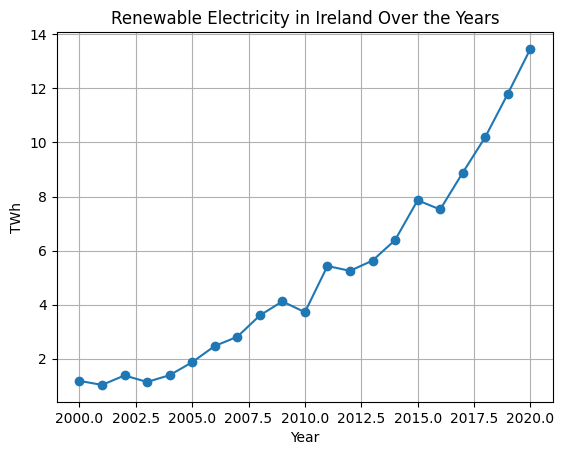

In [ ]:
#ploting renewable energy growth over the years
import matplotlib.pyplot as plt

plt.plot(ireland_df['Year'], ireland_df['Electricity from renewables (TWh)'], marker='o')
plt.title('Renewable Electricity in Ireland Over the Years')
plt.xlabel('Year')
plt.ylabel('TWh')
plt.grid(True)
plt.show()

In [ ]:
#calculating and visualising total or percentage change over a period
start = ireland_df.iloc[0]['Electricity from renewables (TWh)']
end = ireland_df.iloc[-1]['Electricity from renewables (TWh)']
growth = end - start
percentage_growth = (growth / start) * 100

print(f"Total Renewable Energy Growth: {growth:.2f} TWh")
print(f"Percentage Increase: {percentage_growth:.2f}%")


Total Renewable Energy Growth: 12.28 TWh
Percentage Increase: 1040.68%


In [ ]:
#Filtering and cleaning data
df = df.sort_values(by=['Entity', 'Year'])
countries = ['Ireland', 'Germany']
df_filtered = df[df['Entity'].isin(countries)]

In [ ]:
# CO₂ Emissions Trend
df_co2 = df_filtered[['Entity', 'Year', 'Value_co2_emissions_kt_by_country']].dropna()

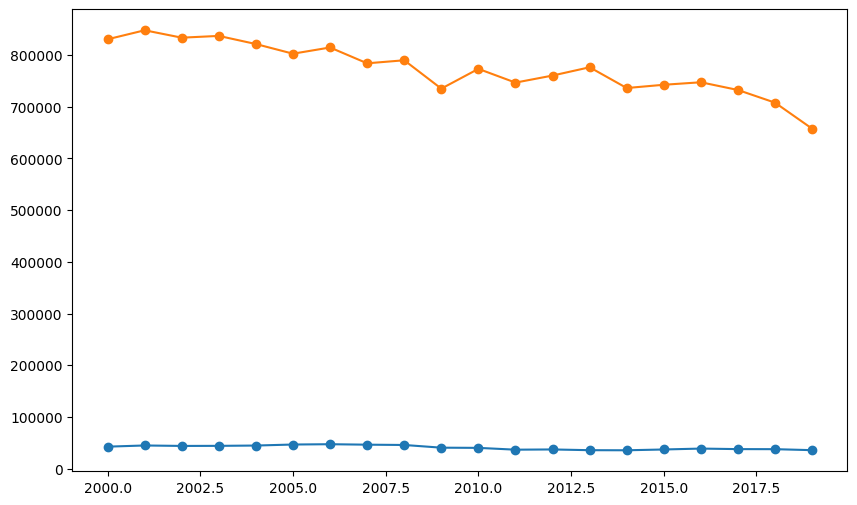

In [ ]:
plt.figure(figsize=(10,6))
for country in countries:
    country_df = df_co2[df_co2['Entity'] == country]
    plt.plot(country_df['Year'], country_df['Value_co2_emissions_kt_by_country'], label=country, marker='o')


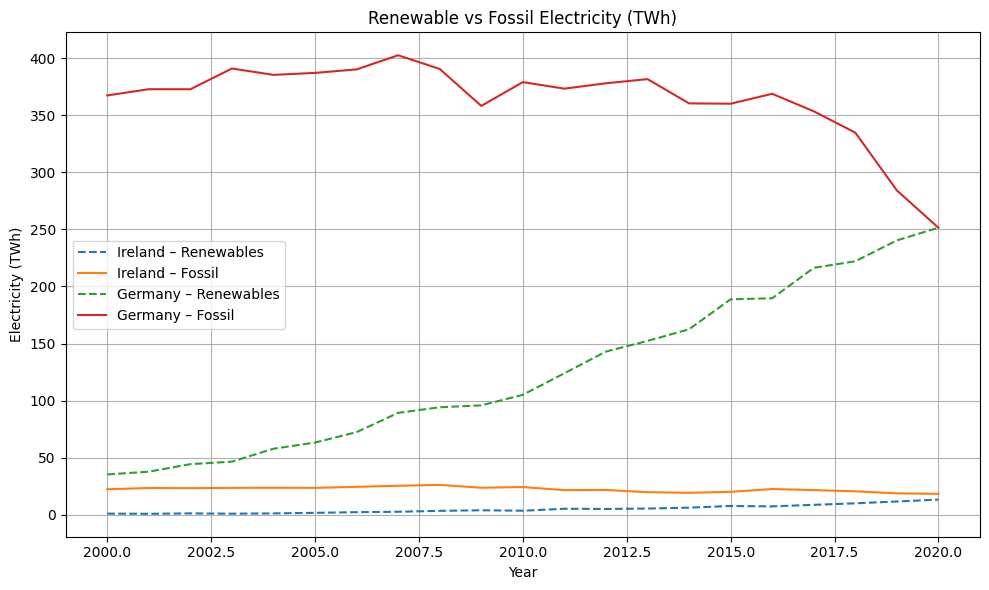

In [ ]:
df_energy = df_filtered[['Entity', 'Year',
                         'Electricity from renewables (TWh)',
                         'Electricity from fossil fuels (TWh)']].dropna()

plt.figure(figsize=(10,6))
for country in countries:
    country_df = df_energy[df_energy['Entity'] == country]
    plt.plot(country_df['Year'], country_df['Electricity from renewables (TWh)'], label=f'{country} – Renewables', linestyle='--')
    plt.plot(country_df['Year'], country_df['Electricity from fossil fuels (TWh)'], label=f'{country} – Fossil', linestyle='-')

plt.title("Renewable vs Fossil Electricity (TWh)")
plt.xlabel("Year")
plt.ylabel("Electricity (TWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Export Clean Dataset for Power BI
df_export = df_filtered[['Entity', 'Year',
                         'Electricity from renewables (TWh)',
                         'Electricity from fossil fuels (TWh)',
                         'Value_co2_emissions_kt_by_country']].dropna()

df_export.to_csv("Ireland_Germany_Energy_CO2_Comparison.csv", index=False)
print("CSV ready for Power BI: Ireland_Germany_Energy_CO2_Comparison.csv")
from google.colab import files
files.download("Ireland_Germany_Energy_CO2_Comparison.csv")


CSV ready for Power BI: Ireland_Germany_Energy_CO2_Comparison.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>